CEK DISTRIBUSI DATA


1. HASIL DISTRIBUSI DATA


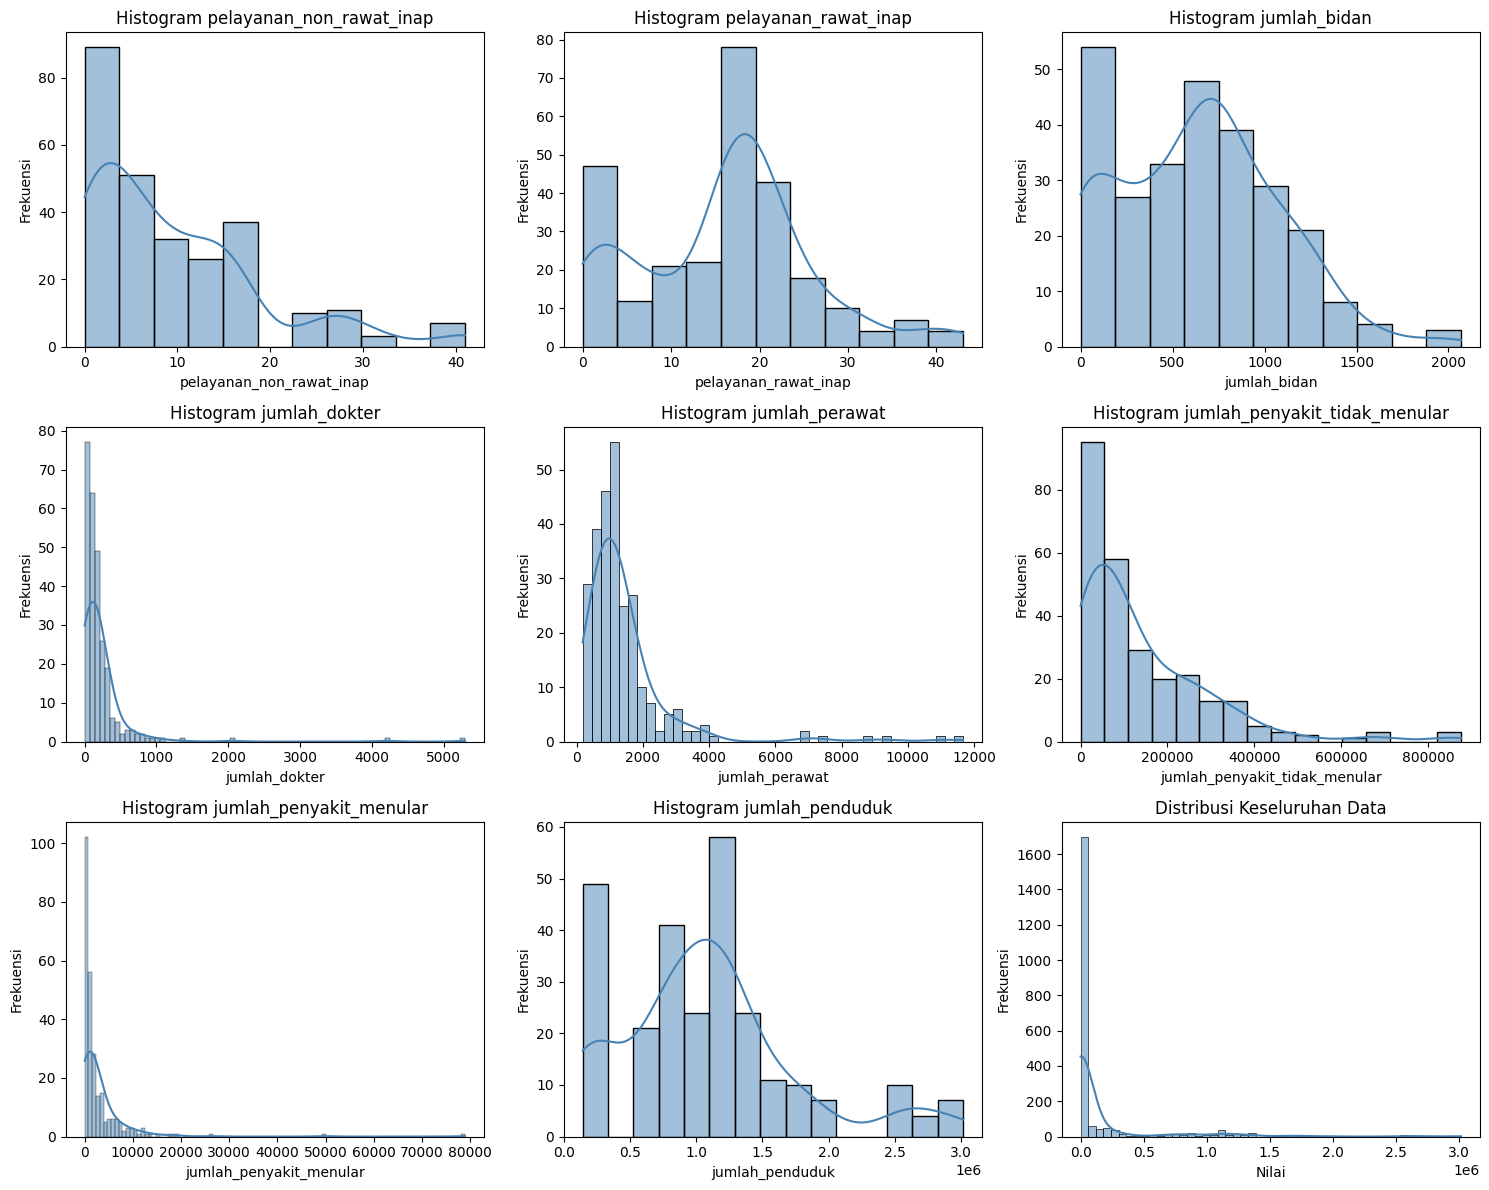


2. HASIL SKEWNESS

pelayanan_non_rawat_inap
Skewness: 1.379
Distribusi miring ke kanan (positive skew)

pelayanan_rawat_inap
Skewness: 0.251
Distribusi relatif simetris

jumlah_bidan
Skewness: 0.353
Distribusi relatif simetris

jumlah_dokter
Skewness: 7.945
Distribusi miring ke kanan (positive skew)

jumlah_perawat
Skewness: 4.153
Distribusi miring ke kanan (positive skew)

jumlah_penyakit_tidak_menular
Skewness: 1.997
Distribusi miring ke kanan (positive skew)

jumlah_penyakit_menular
Skewness: 7.571
Distribusi miring ke kanan (positive skew)

jumlah_penduduk
Skewness: 0.913
Distribusi miring ke kanan (positive skew)

3. UJI NORMALITAS

pelayanan_non_rawat_inap
Statistic : 0.8486
p-value   : 0.0000
Distribusi tidak normal

pelayanan_rawat_inap
Statistic : 0.9447
p-value   : 0.0000
Distribusi tidak normal

jumlah_bidan
Statistic : 0.9635
p-value   : 0.0000
Distribusi tidak normal

jumlah_dokter
Statistic : 0.3599
p-value   : 0.0000
Distribusi tidak normal

jumlah_perawat
Statistic : 0

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, shapiro
import math

# ==============================================================================
# CEK DISTRIBUSI DATA
# ==============================================================================

# --------------------------
# 1. DATA 
# --------------------------
df_distribusi = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')

# --------------------------
# 2. DISTRIBUSI DATA
# --------------------------
kolom_numerik = [
    'pelayanan_non_rawat_inap',
    'pelayanan_rawat_inap',
    'jumlah_bidan',
    'jumlah_dokter',
    'jumlah_perawat',
    'jumlah_penyakit_tidak_menular',
    'jumlah_penyakit_menular',
    'jumlah_penduduk'
]

print("\n1. HASIL DISTRIBUSI DATA")

jumlah_plot = len(kolom_numerik) + 1  # +1 untuk distribusi keseluruhan
ncols = 3
nrows = math.ceil(jumlah_plot / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

# Histogram per kolom
for i, col in enumerate(kolom_numerik):
    sns.histplot(df_distribusi[col], kde=True, color='steelblue', ax=axes[i])

    axes[i].set_title(f'Histogram {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Histogram keseluruhan di plot terakhir
all_values = df_distribusi[kolom_numerik].values.flatten()

sns.histplot(all_values, kde=True, color='steelblue', bins=50)

axes[len(kolom_numerik)].set_title('Distribusi Keseluruhan Data')
axes[len(kolom_numerik)].set_xlabel('Nilai')
axes[len(kolom_numerik)].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# --------------------------
# 3. CEK SKEWNESS
# --------------------------
print("\n2. HASIL SKEWNESS")

for col in kolom_numerik:
    nilai_skew = skew(df_distribusi[col].dropna())

    print(f'\n{col}')
    print(f'Skewness: {nilai_skew:.3f}')

    if -0.5 <= nilai_skew <= 0.5:
        print("Distribusi relatif simetris")
    elif nilai_skew > 0.5:
        print("Distribusi miring ke kanan (positive skew)")
    else:
        print("Distribusi miring ke kiri (negative skew)")

# --------------------------
# 4. UJI NORMALITAS
# --------------------------
print("\n3. UJI NORMALITAS")

for col in kolom_numerik:

    sample_data = df_distribusi[col].dropna()

    # jika data terlalu besar
    if len(sample_data) > 5000:
        sample_data = sample_data.sample(5000, random_state=42)

    stat, p = shapiro(sample_data)

    print(f'\n{col}')
    print(f'Statistic : {stat:.4f}')
    print(f'p-value   : {p:.4f}')

    if p > 0.05:
        print("Distribusi normal")
    else:
        print("Distribusi tidak normal")

In [14]:
from sklearn.preprocessing import StandardScaler

kolom_numerik = [
    'pelayanan_non_rawat_inap',
    'pelayanan_rawat_inap',
    'jumlah_bidan',
    'jumlah_dokter',
    'jumlah_perawat',
    'jumlah_penyakit_tidak_menular',
    'jumlah_penyakit_menular',
    'jumlah_penduduk'
]

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_distribusi[kolom_numerik]),
    columns=kolom_numerik
)

df_scaled.head()

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423485,-0.737864
1,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394990,-0.182574
2,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424552,-0.503987
3,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390723,0.039162
4,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408247,0.220573


setelah normalisasi


1. HASIL DISTRIBUSI DATA


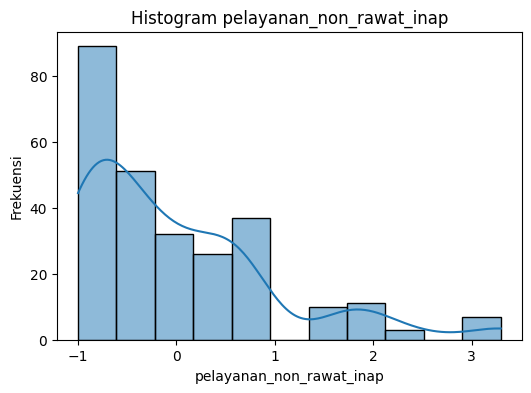

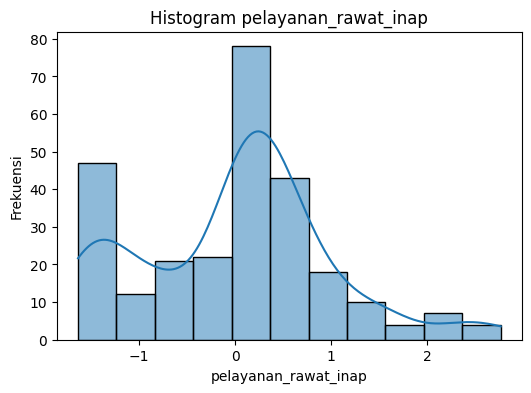

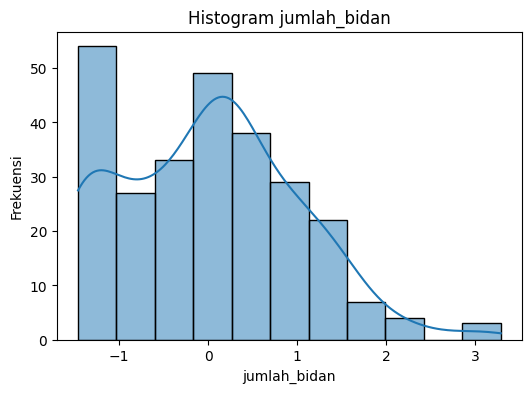

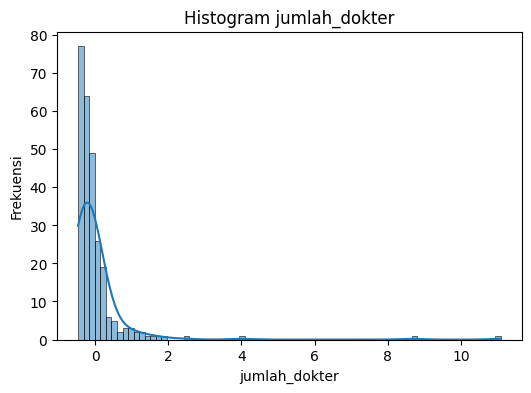

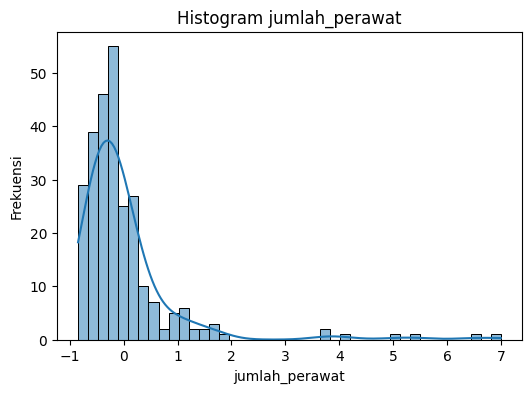

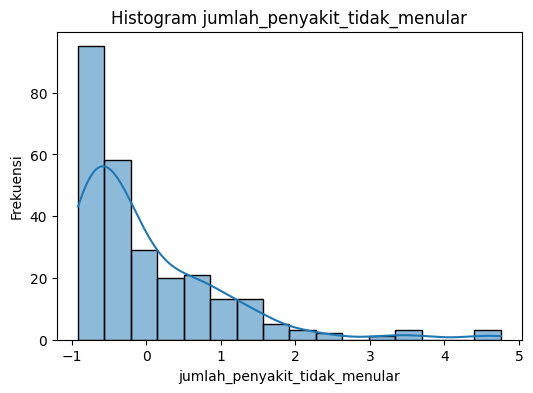

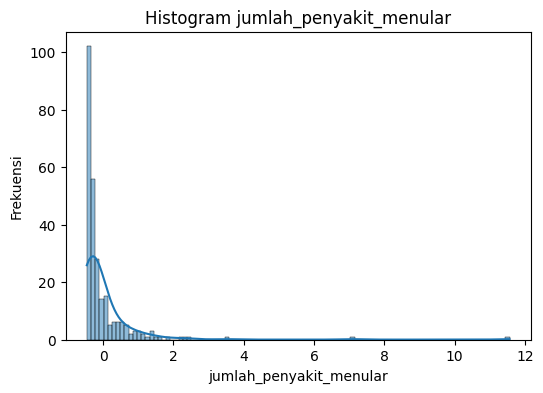

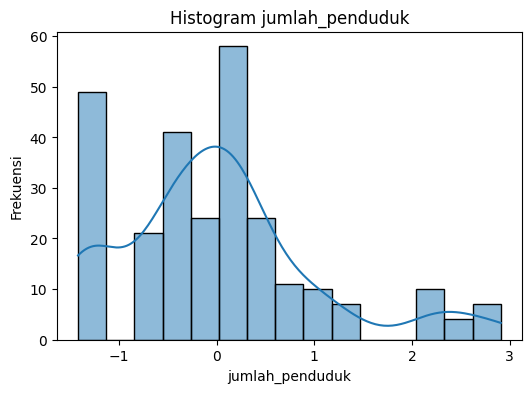

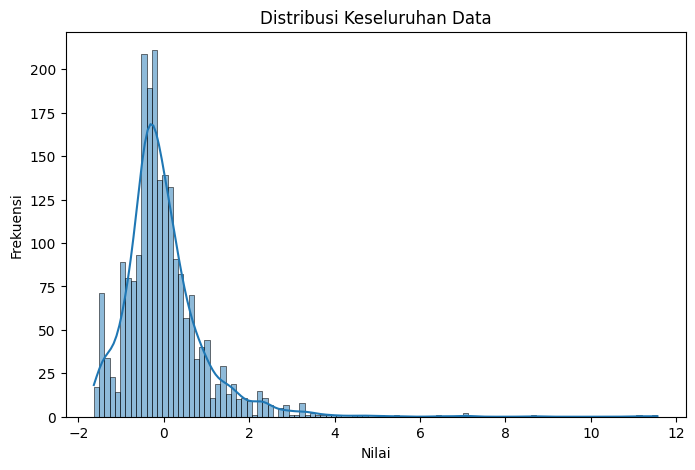


2. HASIL SKEWNESS

pelayanan_non_rawat_inap
Skewness: 1.379
Distribusi miring ke kanan (positive skew)

pelayanan_rawat_inap
Skewness: 0.251
Distribusi relatif simetris

jumlah_bidan
Skewness: 0.353
Distribusi relatif simetris

jumlah_dokter
Skewness: 7.945
Distribusi miring ke kanan (positive skew)

jumlah_perawat
Skewness: 4.153
Distribusi miring ke kanan (positive skew)

jumlah_penyakit_tidak_menular
Skewness: 1.997
Distribusi miring ke kanan (positive skew)

jumlah_penyakit_menular
Skewness: 7.571
Distribusi miring ke kanan (positive skew)

jumlah_penduduk
Skewness: 0.913
Distribusi miring ke kanan (positive skew)

3. UJI NORMALITAS

pelayanan_non_rawat_inap
Statistic : 0.8486
p-value   : 0.0000
Distribusi tidak normal

pelayanan_rawat_inap
Statistic : 0.9447
p-value   : 0.0000
Distribusi tidak normal

jumlah_bidan
Statistic : 0.9635
p-value   : 0.0000
Distribusi tidak normal

jumlah_dokter
Statistic : 0.3599
p-value   : 0.0000
Distribusi tidak normal

jumlah_perawat
Statistic : 0

In [15]:
# --------------------------
# 2. DISTRIBUSI DATA
# --------------------------
kolom_numerik = [
    'pelayanan_non_rawat_inap',
    'pelayanan_rawat_inap',
    'jumlah_bidan',
    'jumlah_dokter',
    'jumlah_perawat',
    'jumlah_penyakit_tidak_menular',
    'jumlah_penyakit_menular',
    'jumlah_penduduk'
]

print("\n1. HASIL DISTRIBUSI DATA")
#per kolom
for col in kolom_numerik:
    plt.figure(figsize=(6,4))
    sns.histplot(df_scaled[col], kde=True)

    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

    plt.show()

#cek semua kolom
all_values = df_scaled[kolom_numerik].values.flatten()

plt.figure(figsize=(8,5))

sns.histplot(all_values, kde=True)

plt.title('Distribusi Keseluruhan Data')
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')

plt.show()

# --------------------------
# 3. CEK SKEWNESS
# --------------------------
print("\n2. HASIL SKEWNESS")

for col in kolom_numerik:
    nilai_skew = skew(df_scaled[col].dropna())

    print(f'\n{col}')
    print(f'Skewness: {nilai_skew:.3f}')

    if -0.5 <= nilai_skew <= 0.5:
        print("Distribusi relatif simetris")
    elif nilai_skew > 0.5:
        print("Distribusi miring ke kanan (positive skew)")
    else:
        print("Distribusi miring ke kiri (negative skew)")

# --------------------------
# 4. UJI NORMALITAS
# --------------------------
print("\n3. UJI NORMALITAS")

for col in kolom_numerik:

    sample_data = df_scaled[col].dropna()

    # jika data terlalu besar
    if len(sample_data) > 5000:
        sample_data = sample_data.sample(5000, random_state=42)

    stat, p = shapiro(sample_data)

    print(f'\n{col}')
    print(f'Statistic : {stat:.4f}')
    print(f'p-value   : {p:.4f}')

    if p > 0.05:
        print("Distribusi normal")
    else:
        print("Distribusi tidak normal")